# Stellar Luminosity: Linear and Polynomial Regression

**Proyecto individual - Regresión desde primeros principios**

Pregunta técnica: **¿cómo aprende un modelo de regresión a partir de datos?**


## 1. Entorno y datos
Alumna: KEYLA YUNUETTE SERNA ILLESCAS


In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print('Python:', sys.version.split()[0]) 
print('Matplotlib:', plt.matplotlib.__version__) 

mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4], dtype=float) 
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0], dtype=float) 

print('mass shape:', mass.shape, '| range:', (mass.min(), mass.max())) 
print('luminosity shape:', luminosity.shape, '| range:', (luminosity.min(), luminosity.max()))


Python: 3.13.14
NumPy: 2.5.1
Matplotlib: 3.11.1
mass shape: (10,) | range: (np.float64(0.6), np.float64(2.4))
luminosity shape: (10,) | range: (np.float64(0.15), np.float64(35.0))


## 2. Exploración antes de modelar

La luminosidad aumenta de forma no lineal al aumentar la masa. Una línea recta probablemente tendrá errores sistemáticos: tenderá a sobreestimar en una zona y subestimar en otra.


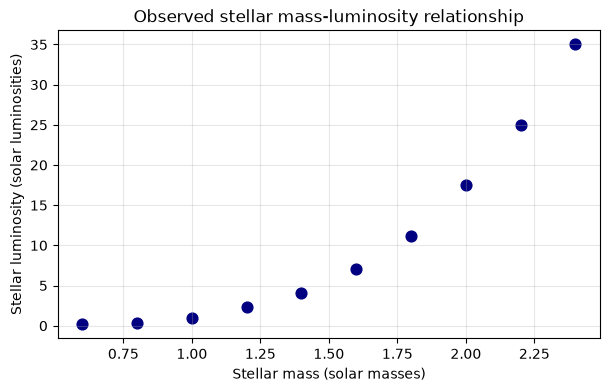

In [ ]:
plt.figure(figsize=(7, 4)) 
plt.scatter(mass, luminosity, color='navy', s=60) 
plt.xlabel('Stellar mass (solar masses)') 
plt.ylabel('Stellar luminosity (solar luminosities)') 
plt.title('Observed stellar mass-luminosity relationship')
plt.grid(alpha=0.3)
plt.show()


## 3. Algoritmo reutilizable y vectorizado

El modelo usa $\hat y = Xw+b$. La función de costo es $J=\frac{1}{2m}\sum(\hat y-y)^2$. Las mismas funciones sirven para una o varias características.


In [ ]:
def predict(X, w, b):
    return X @ w + b

def compute_cost(X, y, w, b): 
    errors = predict(X, w, b) - y
    return np.sum(errors ** 2) / (2 * len(y))

def compute_gradients(X, y, w, b): 
    errors = predict(X, w, b) - y 
    m = len(y)
    return (X.T @ errors) / m, np.sum(errors) / m 

def gradient_descent(X, y, w_init, b_init, alpha, num_iterations): 
    b = float(b_init)
    cost_history = []
    for _ in range(num_iterations): 
        dj_dw, dj_db = compute_gradients(X, y, w, b)
        w -= alpha * dj_dw 
        b -= alpha * dj_db 
        cost_history.append(compute_cost(X, y, w, b))
    return w, b, np.array(cost_history) 


## 4. Modelo lineal

Representación: $X_{linear}=[mass]$. Se entrena el mismo algoritmo con una sola característica.


In [ ]:
X_linear = mass.reshape(-1, 1) 
alpha_linear = 0.01 
iterations_linear = 20000 
w_linear, b_linear, cost_linear = gradient_descent(X_linear, luminosity, np.zeros(1), 0.0, alpha_linear, iterations_linear) 
y_linear = predict(X_linear, w_linear, b_linear) 
print('w:', w_linear)
print('b:', b_linear)
print('final cost:', cost_linear[-1]) 


w: [18.13030296]
b: -16.835454424992403
final cost: 9.795148484848486
MSE: 19.590296969696972


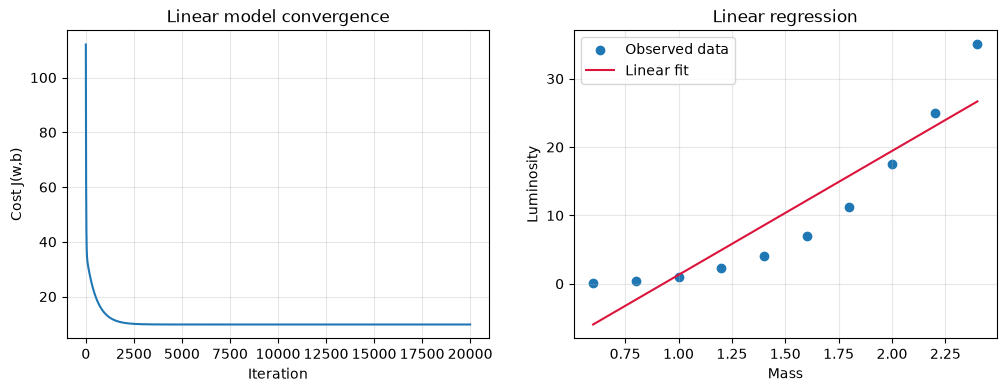

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
ax[0].plot(cost_linear); ax[0].set(title='Linear model convergence', xlabel='Iteration', ylabel='Cost J(w,b)'); ax[0].grid(alpha=.3) 
order = np.argsort(mass) 
ax[1].scatter(mass, luminosity, label='Observed data'); ax[1].plot(mass[order], y_linear[order], color='crimson', label='Linear fit') 
ax[1].set(xlabel='Mass', ylabel='Luminosity', title='Linear regression'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.show() 


**Diagnóstico:** observa los residuos. Si no se distribuyen aleatoriamente alrededor de cero, la línea no captura una parte sistemática de la relación.


## 5. Modelo polinomial

Representación: $X_{polynomial}=[mass, mass^2]$. El algoritmo no cambia; solo cambia la representación de entrada.


In [ ]:
X_polynomial = np.column_stack((mass, mass ** 2))
alpha_polynomial = 0.005 
iterations_polynomial = 30000 
w_poly, b_poly, cost_poly = gradient_descent(X_polynomial, luminosity, np.zeros(2), 0.0, alpha_polynomial, iterations_polynomial)
y_poly = predict(X_polynomial, w_poly, b_poly)
print('w:', w_poly)
print('b:', b_poly)
print('final cost:', cost_poly[-1])
print('MSE:', np.mean((y_poly - luminosity) ** 2))

w: [-16.27623623  11.59478346]
b: 4.818001657064743
final cost: 0.8239204449410693
MSE: 1.6478408898821386


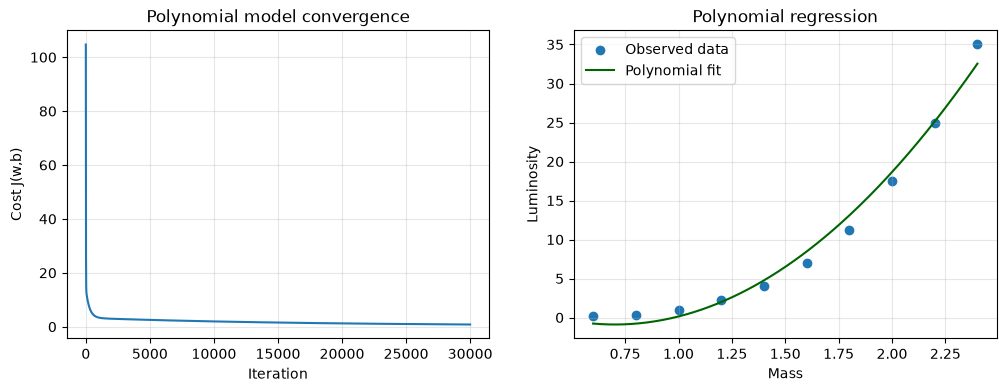

In [ ]:
mass_grid = np.linspace(mass.min(), mass.max(), 200) 
X_grid_poly = np.column_stack((mass_grid, mass_grid ** 2)) 
fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
ax[0].plot(cost_poly); ax[0].set(title='Polynomial model convergence', xlabel='Iteration', ylabel='Cost J(w,b)'); ax[0].grid(alpha=.3) 
ax[1].scatter(mass, luminosity, label='Observed data'); ax[1].plot(mass_grid, predict(X_grid_poly, w_poly, b_poly), color='darkgreen', label='Polynomial fit') 
ax[1].set(xlabel='Mass', ylabel='Luminosity', title='Polynomial regression'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.show()


## 6. Comparación: costos, residuos y visualización

Un costo menor dentro del entrenamiento no prueba por sí solo que el modelo sea científicamente válido. Solo indica que se ajustó mejor a estos datos.


Linear final cost: 9.795148
Polynomial final cost: 0.823920
Linear MSE: 19.590297
Polynomial MSE: 1.647841


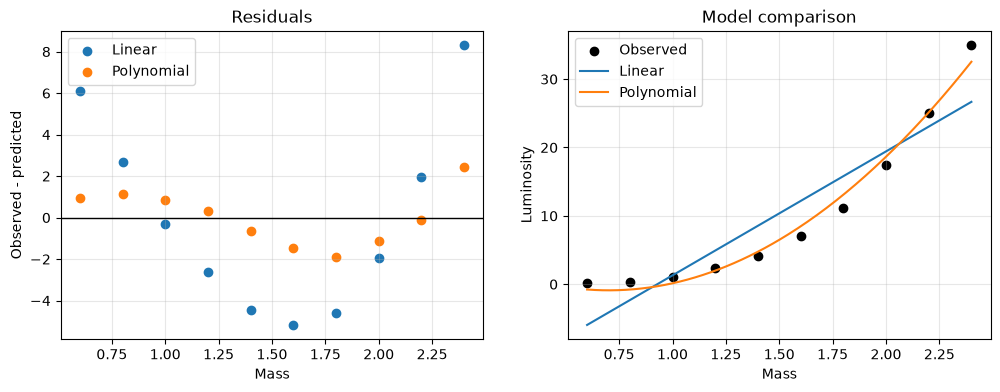

In [ ]:
residual_linear = luminosity - y_linear 
residual_poly = luminosity - y_poly 
print(f'Linear final cost: {cost_linear[-1]:.6f}') 
print(f'Polynomial final cost: {cost_poly[-1]:.6f}') 
print(f'Linear MSE: {np.mean(residual_linear**2):.6f}') 
print(f'Polynomial MSE: {np.mean(residual_poly**2):.6f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4)) 
ax[0].axhline(0, color='black', linewidth=1); ax[0].scatter(mass, residual_linear, label='Linear'); ax[0].scatter(mass, residual_poly, label='Polynomial') 
ax[0].set(title='Residuals', xlabel='Mass', ylabel='Observed - predicted'); ax[0].legend(); ax[0].grid(alpha=.3) 
ax[1].plot(mass_grid, predict(mass_grid.reshape(-1,1), w_linear, b_linear), label='Linear') 
ax[1].plot(mass_grid, predict(X_grid_poly, w_poly, b_poly), label='Polynomial') 
ax[1].set(title='Model comparison', xlabel='Mass', ylabel='Luminosity'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.show()


## 7. Límite de la evidencia: interpolación y extrapolación

Masa 1.3 está dentro del rango observado; masa 5.0 está muy fuera. La predicción fuera del rango debe interpretarse con mucha cautela.


In [ ]:
test_mass = np.array([1.3, 5.0])
linear_test = predict(test_mass.reshape(-1, 1), w_linear, b_linear) 
poly_test = predict(np.column_stack((test_mass, test_mass**2)), w_poly, b_poly) 
for value, linear_value, poly_value in zip(test_mass, linear_test, poly_test): 
    location = 'inside observed range' if mass.min() <= value <= mass.max() else 'outside observed range'
    print(f'mass={value} ({location}): linear={linear_value:.3f}, polynomial={poly_value:.3f}') 


mass=1.3 (inside observed range): linear=6.734, polynomial=3.254
mass=5.0 (outside observed range): linear=73.816, polynomial=213.306


## 8. Reflexión personal sobre IA

Escribe respuestas personales y concisas después de revisar tus resultados.

1. ¿Qué revela y qué no revela este experimento sobre cómo aprenden sistemas de IA más avanzados?

**Respuesta:** [En este experimento mostramos que el modelo de regresión aprende alineando sus parámetros para así poder reducir el error a través de las predicciones. De igual forma, muestra que al representar los datos, al agregar mass², el modelo polinomial alcanzó un costo y un MSE mucho menor que el modelo lineal]

2. ¿Crees que la AGI es alcanzable? Define con tus palabras AGI y justifica tu postura.

**Respuesta:** [Teniendo en cuenta que AGI, Artificial General Intelligence (por sus siglas en inglés), sería una IA con distintas capacidades como aprender, razonar, entre otros. Yo considero que sí sería alcanzable en el futuro. En lo personal, AGI sería capaz de entender, razonar y resolver problemas nuevos en disfentes contextos, usar sus conocimientos previos para la resolución de nuesvos pronlemas, algo más parecido al aprendizaje humano. Los modelos de IA que conocemos en la actualidad, siguen realizando cosas realmente impresionantes que anteriormente parecía complejo, pero siguen aprendiendo bastante de los datos con los que han sido entrenados, y aún suelen cometer errores. Pienso que para lograr AGI sería dar un gran salto en el mundo de la tecnología.]

3. ¿Basta escalar redes neuronales con más GPU, datos y parámetros, o se necesitan ideas fundamentalmente distintas?

**Respuesta:** [Podrían mejorar demasiado las capacidades de los modelos que hay en la actualidad, pero no creo que escalar por sí solo garantice AGI. El experimento de regresión muestra una idea similar, el modo polinominal mejora al tener una mejor presentación, no solo porque se entrenó más tiempo.]

4. Una pregunta sobre sistemas impulsados por IA que quiero explorar este semestre es:
Considero que este es uno de los temas más profundos y que sin duda se pueden explorar distintas ramas. Pero... ¿Cómo podríamos saber si un sistema de IA realmente comprende u  problema o solo identifica patrones con los datos que fue entrenado?
